# Modeling

## Objective

The goal of this notebook is to select the most suitable baseline model for fraud transaction detection under a highly imbalanced classification setting.

This task is not only about achieving a high overall score, but about finding a model that can detect fraudulent transactions effectively while keeping false alarms at a manageable level. In fraud detection, missing a fraudulent transaction is costly, but generating too many false positives also creates operational burden for downstream review and monitoring systems.

Therefore, the model selection process in this notebook focuses on both **predictive quality** and **practical usability**.

In [36]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from xgboost import XGBClassifier
from math import ceil

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 200)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

CONFIG_PATH = PROJECT_ROOT / "configs" / "model_config.yaml"

TRAIN_LOG_PATH = PROJECT_ROOT / "data" / "processed" / "train_log.parquet"
VALID_LOG_PATH = PROJECT_ROOT / "data" / "processed" / "valid_log.parquet"

TRAIN_TREE_PATH = PROJECT_ROOT / "data" / "processed" / "train_tree.parquet"
VALID_TREE_PATH = PROJECT_ROOT / "data" / "processed" / "valid_tree.parquet"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("TRAIN_LOG_PATH:", TRAIN_LOG_PATH)
print("VALID_LOG_PATH:", VALID_LOG_PATH)
print("TRAIN_TREE_PATH:", TRAIN_TREE_PATH)
print("VALID_TREE_PATH:", VALID_TREE_PATH)

PROJECT_ROOT: E:\ML oops\mlops-project
CONFIG_PATH: E:\ML oops\mlops-project\configs\model_config.yaml
TRAIN_LOG_PATH: E:\ML oops\mlops-project\data\processed\train_log.parquet
VALID_LOG_PATH: E:\ML oops\mlops-project\data\processed\valid_log.parquet
TRAIN_TREE_PATH: E:\ML oops\mlops-project\data\processed\train_tree.parquet
VALID_TREE_PATH: E:\ML oops\mlops-project\data\processed\valid_tree.parquet


## 1. Helper Functions

These helper functions are adapted from the production script:
- config loading
- parquet loading
- datetime cleanup
- train/target splitting
- optional SMOTE
- model instantiation
- metric computation
- feature importance extraction

In [3]:
def load_yaml(path: str | Path) -> dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def load_table(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Unsupported file format: {path.suffix}")


def drop_datetime_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if dt_cols:
        print(f"Dropping datetime columns: {dt_cols}")
        df = df.drop(columns=dt_cols)
    return df


def split_xy(df: pd.DataFrame, target: str) -> tuple[pd.DataFrame, pd.Series]:
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found")
    x = df.drop(columns=[target])
    y = df[target].astype(int)
    return x, y


def maybe_apply_smote(
    x_train: pd.DataFrame,
    y_train: pd.Series,
    use_smote: bool,
    random_state: int,
) -> tuple[pd.DataFrame, pd.Series]:
    if not use_smote:
        return x_train, y_train

    smote = SMOTE(random_state=random_state)
    x_res, y_res = smote.fit_resample(x_train, y_train)

    x_res = pd.DataFrame(x_res, columns=x_train.columns)
    y_res = pd.Series(y_res, name=y_train.name)

    return x_res, y_res


def get_model_instance(model_name: str, params: dict[str, Any]) -> Any:
    model_map = {
        "logistic_regression": LogisticRegression,
        "xgboost": XGBClassifier,
        "lightgbm": LGBMClassifier,
        "catboost": CatBoostClassifier,
    }
    if model_name not in model_map:
        raise ValueError(f"Unsupported model: {model_name}")
    return model_map[model_name](**params)


def compute_metrics(y_true: pd.Series, y_pred: np.ndarray, y_score: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
    }


def build_feature_importance_df(model: Any, feature_names: list[str]) -> pd.DataFrame | None:
    if hasattr(model, "feature_importances_"):
        return (
            pd.DataFrame({"feature": feature_names, "importance": model.feature_importances_})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

    if hasattr(model, "coef_"):
        coef = np.abs(model.coef_).ravel()
        return (
            pd.DataFrame({"feature": feature_names, "importance": coef})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

    return None

## 2. Plotting Functions

In this notebook, we display them directly for analysis and reporting.

In [4]:
def plot_confusion_matrix(y_true: pd.Series, y_pred: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        ax=ax,
        colorbar=False,
        cmap=plt.cm.Blues,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_pr_curve(y_true: pd.Series, y_score: np.ndarray, title: str) -> None:
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true: pd.Series, y_score: np.ndarray, title: str) -> None:
    fpr, tpr, _ = roc_curve(y_true, y_score)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(importance_df: pd.DataFrame, title: str, top_n: int = 15) -> None:
    plot_df = importance_df.head(top_n).sort_values("importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(plot_df["feature"], plot_df["importance"])
    ax.set_title(title)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 3. Load Config and Processed Datasets


In [8]:
cfg = load_yaml(CONFIG_PATH)

experiment_cfg = cfg["experiment"]
target = experiment_cfg["target"]
experiment_name = experiment_cfg["name"]
selection_metric = experiment_cfg["selection_metric"]

resampling_cfg = cfg.get("resampling", {})
use_smote = bool(resampling_cfg.get("use_smote", False))
smote_random_state = int(resampling_cfg.get("random_state", 42))

print("Experiment name :", experiment_name)
print("Target          :", target)
print("Selection metric:", selection_metric)
print("Use SMOTE       :", use_smote)
print("SMOTE seed      :", smote_random_state)

# Load Processed Data
train_log = load_table(TRAIN_LOG_PATH)
valid_log = load_table(VALID_LOG_PATH)

train_tree = load_table(TRAIN_TREE_PATH)
valid_tree = load_table(VALID_TREE_PATH)

print("train_log shape :", train_log.shape)
print("valid_log shape :", valid_log.shape)
print("train_tree shape:", train_tree.shape)
print("valid_tree shape:", valid_tree.shape)

Experiment name : fraud-model-selection
Target          : is_fraud
Selection metric: pr_auc
Use SMOTE       : True
SMOTE seed      : 42
train_log shape : (532868, 96)
valid_log shape : (133217, 96)
train_tree shape: (532868, 27)
valid_tree shape: (133217, 27)


In [9]:
dataset_summary = pd.DataFrame(
    [
        {
            "dataset": "train_log",
            "rows": len(train_log),
            "cols": train_log.shape[1],
            "fraud_count": int(train_log[target].sum()),
            "fraud_rate": float(train_log[target].mean()),
        },
        {
            "dataset": "valid_log",
            "rows": len(valid_log),
            "cols": valid_log.shape[1],
            "fraud_count": int(valid_log[target].sum()),
            "fraud_rate": float(valid_log[target].mean()),
        },
        {
            "dataset": "train_tree",
            "rows": len(train_tree),
            "cols": train_tree.shape[1],
            "fraud_count": int(train_tree[target].sum()),
            "fraud_rate": float(train_tree[target].mean()),
        },
        {
            "dataset": "valid_tree",
            "rows": len(valid_tree),
            "cols": valid_tree.shape[1],
            "fraud_count": int(valid_tree[target].sum()),
            "fraud_rate": float(valid_tree[target].mean()),
        },
    ]
)

dataset_summary

,dataset,rows,cols,fraud_count,fraud_rate
0,train_log,532868,96,9111,0.017098
1,valid_log,133217,96,2307,0.017318
2,train_tree,532868,27,9111,0.017098
3,valid_tree,133217,27,2307,0.017318


### Problem characteristics

Fraud detection is a challenging machine learning problem because the target class is highly imbalanced: fraudulent transactions represent only a very small portion of the data, while normal transactions dominate the dataset.

This class imbalance has two important implications:

1. A model can achieve very high **accuracy** simply by predicting most transactions as non-fraud.
2. Evaluation must focus more strongly on how well the model performs on the **fraud class**, rather than on aggregate correctness alone.

For this reason, model assessment in this notebook goes beyond accuracy and emphasizes metrics that better capture minority-class performance.

In [11]:
x_train_log, y_train_log = split_xy(train_log, target)
x_valid_log, y_valid_log = split_xy(valid_log, target)

x_train_tree, y_train_tree = split_xy(train_tree, target)
x_valid_tree, y_valid_tree = split_xy(valid_tree, target)

x_train_log = drop_datetime_columns(x_train_log)
x_valid_log = drop_datetime_columns(x_valid_log)

x_train_tree = drop_datetime_columns(x_train_tree)
x_valid_tree = drop_datetime_columns(x_valid_tree)

print("x_train_log :", x_train_log.shape)
print("x_valid_log :", x_valid_log.shape)
print("x_train_tree:", x_train_tree.shape)
print("x_valid_tree:", x_valid_tree.shape)

x_train_log : (532868, 95)
x_valid_log : (133217, 95)
x_train_tree: (532868, 26)
x_valid_tree: (133217, 26)


## 4. Notebook Training Function

It will:
- optionally apply SMOTE,
- fit the model,
- compute validation metrics,
- store predictions and probabilities,
- and prepare feature importance for plotting.

In [12]:
def train_and_evaluate(
    model_name: str,
    display_name: str,
    model: Any,
    x_train: pd.DataFrame,
    y_train: pd.Series,
    x_valid: pd.DataFrame,
    y_valid: pd.Series,
    selection_metric: str,
    use_smote: bool,
    smote_random_state: int,
) -> dict[str, Any]:
    x_fit, y_fit = maybe_apply_smote(x_train, y_train, use_smote, smote_random_state)

    model.fit(x_fit, y_fit)

    y_pred = model.predict(x_valid)
    y_score = model.predict_proba(x_valid)[:, 1]

    y_pred = np.array(y_pred).reshape(-1).astype(int)
    y_score = np.array(y_score).reshape(-1)

    metrics = compute_metrics(y_valid, y_pred, y_score)
    importance_df = build_feature_importance_df(model, x_train.columns.tolist())

    return {
        "model_name": model_name,
        "display_name": display_name,
        "selection_score": metrics[selection_metric],
        **metrics,
        "use_smote": use_smote,
        "model": model,
        "y_valid_true": y_valid,
        "y_valid_pred": y_pred,
        "y_valid_score": y_score,
        "feature_importance_df": importance_df,
    }

### Model comparison strategy

To build a reliable baseline comparison, this notebook evaluates four models:

- Logistic Regression
- XGBoost
- LightGBM
- CatBoost

These models were chosen to cover both a simple interpretable baseline and several strong nonlinear ensemble methods for tabular data.

**Logistic Regression** provides a useful benchmark because it is simple, fast, and easy to interpret. However, fraud detection patterns are often nonlinear and depend on complex interactions between behavioral, temporal, and transactional signals. For this reason, gradient boosting models are expected to perform better in this setting.

The comparison is not based on a single table alone. Instead, the notebook combines:

- quantitative metrics from the leaderboard,
- confusion matrices,
- Precision–Recall curves,
- and feature importance analysis.

This provides a more complete basis for model selection.

In [14]:
model_results: list[dict[str, Any]] = []

for model_name, model_cfg in cfg["models"].items():
    if not model_cfg.get("enabled", False):
        continue

    dataset_branch = model_cfg["dataset"]
    params = model_cfg["params"]
    model = get_model_instance(model_name, params)

    if dataset_branch == "log":
        x_train, y_train, x_valid, y_valid = x_train_log, y_train_log, x_valid_log, y_valid_log
    elif dataset_branch == "tree":
        x_train, y_train, x_valid, y_valid = x_train_tree, y_train_tree, x_valid_tree, y_valid_tree
    else:
        raise ValueError(f"Unsupported dataset branch: {dataset_branch}")

    display_name = model_name.replace("_", " ").title()

    result = train_and_evaluate(
        model_name=model_name,
        display_name=display_name,
        model=model,
        x_train=x_train,
        y_train=y_train,
        x_valid=x_valid,
        y_valid=y_valid,
        selection_metric=selection_metric,
        use_smote=use_smote,
        smote_random_state=smote_random_state,
    )

    result["dataset"] = dataset_branch
    result["baseline_params"] = params
    model_results.append(result)

    print(f"Finished: {display_name}")

Finished: Logistic Regression
Finished: Xgboost
[LightGBM] [Info] Number of positive: 523757, number of negative: 523757
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1886
[LightGBM] [Info] Number of data points in the train set: 1047514, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Finished: Lightgbm
Finished: Catboost


## 5. Build Validation Leaderboard

### Why PR-AUC is the primary selection metric

In this notebook, **PR-AUC (Area Under the Precision–Recall Curve)** is used as the primary metric for model selection.

This choice is especially important for fraud detection because the dataset is highly imbalanced. In such settings, metrics like **accuracy** can be misleading, and even **ROC-AUC** may still look very high while the model is not yet strong enough on the minority fraud class.

PR-AUC is more suitable because it focuses directly on the relationship between **precision** and **recall**, which are the two most critical metrics in fraud detection:

- **Precision** measures how many flagged transactions are actually fraud.
- **Recall** measures how many real fraud cases the model is able to capture.

This makes PR-AUC a better summary of model quality for this task. More importantly, PR-AUC is also useful from a deployment perspective: it reflects how well the model balances precision and recall **across different operating points**, which is highly valuable for **threshold selection later on**.

In other words, a model with stronger PR-AUC is not only better in current validation, but is also more likely to remain flexible and effective when the decision threshold is adjusted later to match business goals, such as reducing false alarms or increasing fraud capture.

For this reason, PR-AUC is a more practical and future-oriented metric than accuracy for selecting the final fraud detection model.

In [18]:
if not model_results:
    raise ValueError("No enabled models found in config['models'].")

leaderboard = pd.DataFrame(
    [
        {
            "model_name": r["model_name"],
            "display_name": r["display_name"],
            "dataset": r["dataset"],
            "use_smote": r["use_smote"],
            "selection_score": r["selection_score"],
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1_score": r["f1_score"],
            "roc_auc": r["roc_auc"],
            "pr_auc": r["pr_auc"],
        }
        for r in model_results
    ]
).sort_values(by="selection_score", ascending=False).reset_index(drop=True)

leaderboard.style.background_gradient(
    subset=["pr_auc", "roc_auc", "f1_score", "precision", "recall"],
    cmap="Blues"
)

,model_name,display_name,dataset,use_smote,selection_score,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,lightgbm,Lightgbm,tree,True,0.852391,0.992478,0.801108,0.752492,0.776039,0.994015,0.852391
1,xgboost,Xgboost,tree,True,0.845002,0.992126,0.777827,0.763329,0.770510,0.993292,0.845002
2,catboost,Catboost,tree,True,0.842633,0.992088,0.781320,0.754226,0.767534,0.993415,0.842633
3,logistic_regression,Logistic Regression,log,True,0.799660,0.955967,0.274661,0.940182,0.425127,0.990080,0.799660


### Model-by-Model Interpretation

---

#### Logistic Regression: strengths and weaknesses

Logistic Regression is the most aggressive model in the comparison.

Its main strength is **very high recall**: it misses only a small number of fraud cases, which means it is highly sensitive to suspicious behavior. This can be attractive in a risk-sensitive setting where the cost of a missed fraud is considered extremely high.

However, that sensitivity comes with a major downside: **precision is very low**. The confusion matrix shows that Logistic Regression generates a very large number of false positives relative to the other models. In practical terms, this means the model would overwhelm downstream review systems with alerts, many of which would turn out not to be fraud.

This pattern suggests that Logistic Regression is useful as a **recall-oriented baseline**, but not as the strongest production candidate. It proves that the feature pipeline contains fraud signal, but it also shows that a linear model is too limited to rank suspicious transactions cleanly enough in this problem.

---

#### XGBoost: strongest recall among the boosting models

XGBoost is the most recall-oriented model among the three boosting candidates.

Compared with LightGBM and CatBoost, it captures slightly more fraud cases and produces fewer false negatives. This suggests that XGBoost is somewhat more aggressive in identifying suspicious transactions, while still keeping false positives under control far better than Logistic Regression.

Its weakness is that this gain in recall comes with slightly lower precision and slightly weaker PR-AUC than LightGBM. In other words, XGBoost is very competitive, but its ranking quality is not quite as clean at the top end.

From a business perspective, XGBoost would be attractive if the project prioritizes **catching slightly more fraud**, and can tolerate a small increase in false alerts. It is therefore a strong alternative model, especially in scenarios where missing fraud is judged to be more costly than reviewing additional flagged transactions.

---

#### LightGBM: best overall balance

LightGBM is the strongest overall model in the current benchmark.

Its most important advantage is that it achieves the **highest PR-AUC**, which means it provides the best precision–recall behavior across thresholds rather than only at one fixed operating point. This is especially valuable for fraud detection because the final deployment threshold may later be tuned depending on business priorities.

At the default evaluation point, LightGBM also achieves the **highest precision** among all compared models, while maintaining recall that remains competitive with the other boosting models. This indicates that it is the cleanest alert generator: among the transactions it flags as fraud, the fraction of truly fraudulent cases is the highest.

The cost of this stronger precision is a small drop in recall relative to XGBoost. However, that recall difference is modest, while the gain in precision and PR-AUC is meaningful. For that reason, LightGBM provides the most practical and balanced fraud detection profile in this notebook.

---

#### CatBoost: strong and stable, but not the best on the main criteria

CatBoost also performs strongly and remains very close to the other boosting models.

Its confusion matrix and metric profile show that it behaves as a balanced model, with precision and recall both at strong levels. It clearly outperforms Logistic Regression and is a valid high-quality fraud detection candidate.

However, CatBoost is slightly behind LightGBM on PR-AUC and precision, and slightly behind XGBoost on recall. This means it does not dominate the comparison on the main selection criteria. Instead, it behaves more like a robust middle-ground model.

In the current benchmark, CatBoost is best interpreted as a **credible alternative** rather than the final winner. It confirms that gradient boosting is the right model family for this task, but it is not the strongest single model under the current evaluation setup.

### Leaderboard interpretation

The leaderboard shows a clear separation between the linear baseline and the boosting-based models.

A first important observation is that the boosting models consistently outperform Logistic Regression in overall fraud detection quality. This suggests that the fraud patterns in the dataset are not purely linear and benefit from models that can capture more complex feature interactions.

A second important observation is that Logistic Regression tends to achieve very high recall, but at the cost of much lower precision. This means it is aggressive in flagging suspicious transactions: it catches many fraud cases, but it also produces many false alarms.

By contrast, the boosting models provide a much more balanced performance profile. They maintain strong recall while improving precision substantially, which is more suitable for a practical fraud detection system.

Among them, **LightGBM** stands out as the strongest candidate because it achieves the best overall balance between fraud capture and false positive control, while also ranking highest on the primary metric, PR-AUC.

## 6. Compare Models Visually

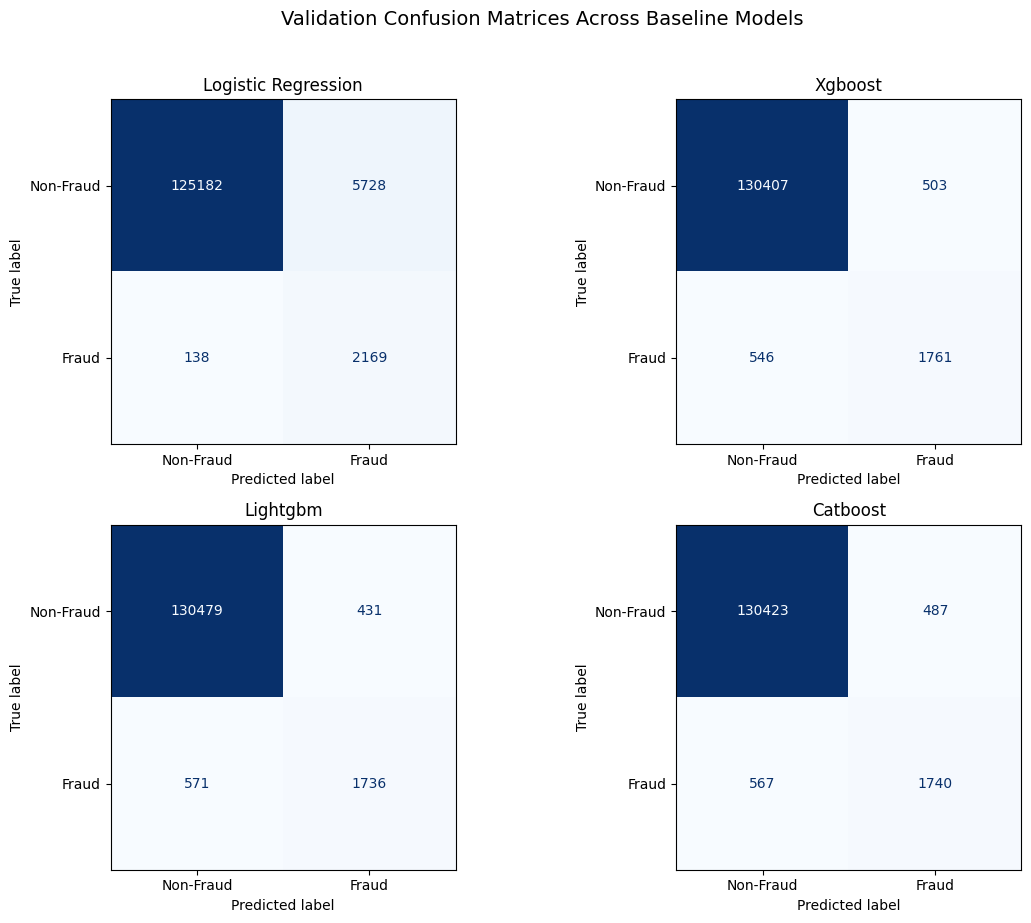

In [37]:
def plot_all_confusion_matrices(model_results, ncols=2):
    n_models = len(model_results)
    nrows = ceil(n_models / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, result in zip(axes, model_results):
        ConfusionMatrixDisplay.from_predictions(
            result["y_valid_true"],
            result["y_valid_pred"],
            display_labels=["Non-Fraud", "Fraud"],
            ax=ax,
            colorbar=False,
            cmap=plt.cm.Blues,
            values_format="d",
        )
        ax.set_title(result["display_name"])

    for ax in axes[len(model_results):]:
        ax.axis("off")

    fig.suptitle("Validation Confusion Matrices Across Baseline Models", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_confusion_matrices(model_results, ncols=2)

### Confusion matrix interpretation

The confusion matrices make the trade-offs concrete.

For fraud detection, the two most important error types are:

- **False Negatives (FN):** missed fraud cases.
- **False Positives (FP):** normal transactions incorrectly flagged as fraud.

Logistic Regression produces the fewest false negatives, which explains its very high recall. However, it does so by creating a massive increase in false positives. This makes it highly sensitive, but operationally expensive.

The three boosting models all reduce false positives dramatically. Among them, **LightGBM produces the fewest false positives**, which is consistent with its highest precision. **XGBoost produces slightly fewer false negatives**, which explains its slightly higher recall. **CatBoost sits between them** and remains close on both error types.

This makes the trade-off very clear:

- If the objective is **maximum fraud capture**, Logistic Regression or XGBoost may look attractive.
- If the objective is **better alert quality with still-strong fraud detection**, LightGBM is the strongest choice.

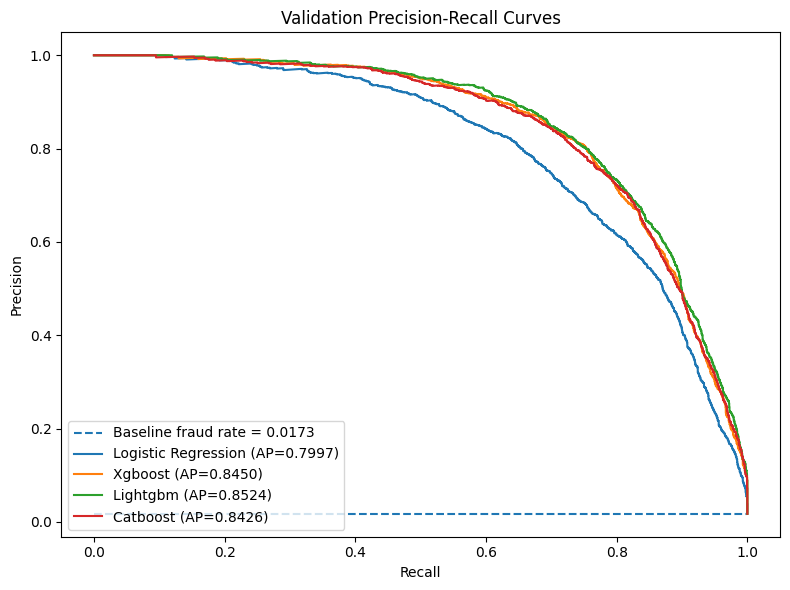

In [38]:
def plot_all_pr_curves(model_results):
    fig, ax = plt.subplots(figsize=(8, 6))

    # baseline fraud rate
    y_ref = model_results[0]["y_valid_true"]
    fraud_rate = np.mean(y_ref)
    ax.hlines(
        y=fraud_rate,
        xmin=0,
        xmax=1,
        linestyles="--",
        label=f"Baseline fraud rate = {fraud_rate:.4f}",
    )

    for result in model_results:
        y_true = result["y_valid_true"]
        y_score = result["y_valid_score"]

        precision, recall, _ = precision_recall_curve(y_true, y_score)
        pr_auc = average_precision_score(y_true, y_score)

        ax.plot(
            recall,
            precision,
            label=f"{result['display_name']} (AP={pr_auc:.4f})",
        )

    ax.set_title("Validation Precision-Recall Curves")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


plot_all_pr_curves(model_results)

### Precision–Recall curve interpretation

The Precision–Recall curves provide one of the most important views in this notebook.

Unlike a confusion matrix, which only evaluates the model at one chosen threshold, the PR curve shows how precision changes as recall increases across many thresholds. This is crucial in fraud detection, because the final system may later need to shift its operating point depending on review capacity, risk appetite, or changing fraud patterns.

Several important conclusions emerge from the curves:

1. **Logistic Regression is consistently weaker than the boosting models across most of the recall range.**  
   This confirms that its fraud ranking quality is inferior, even though its recall at the default threshold is very high.

2. **The three boosting models are tightly clustered, but LightGBM generally stays on or above the others across a large portion of the curve.**  
   This supports its highest PR-AUC and indicates that it offers the strongest overall ranking quality.

3. **As recall approaches very high levels, all models experience a precision drop.**  
   This is expected in imbalanced fraud detection: pushing the system to catch nearly every fraud case inevitably pulls in more false positives.

The most important implication is that **LightGBM is not only strong at the current threshold, but is also the best starting point for later threshold tuning**, because its ranking quality is strongest across operating points.

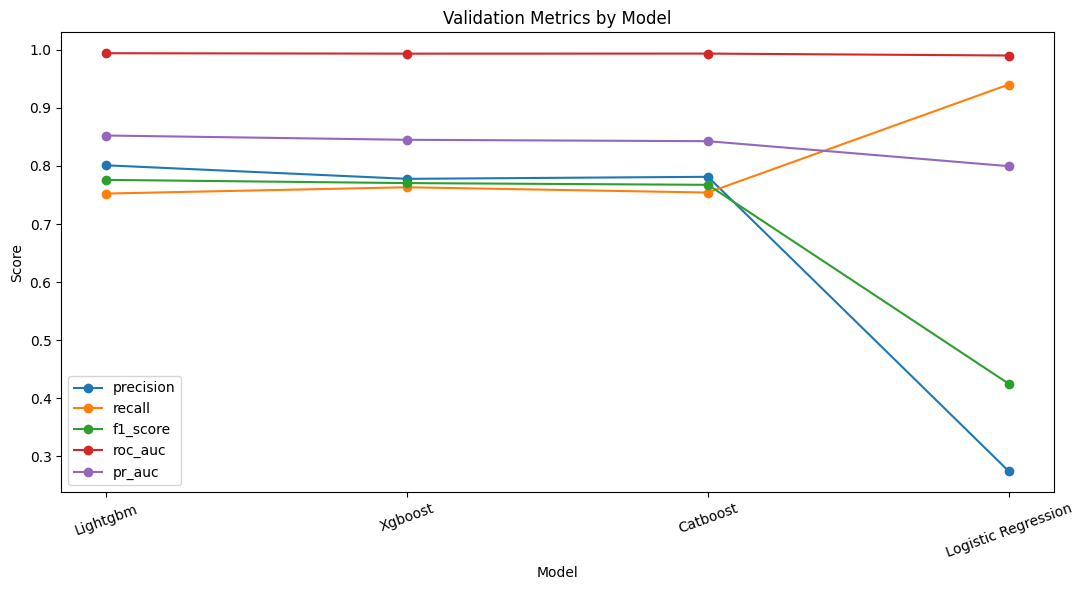

In [39]:
metric_cols = ["precision", "recall", "f1_score", "roc_auc", "pr_auc"]

leaderboard_long = leaderboard.melt(
    id_vars=["display_name"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(11, 6))

for metric in metric_cols:
    subset = leaderboard_long[leaderboard_long["metric"] == metric]
    ax.plot(subset["display_name"], subset["value"], marker="o", label=metric)

ax.set_title("Validation Metrics by Model")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Why PR-AUC matters more than ROC-AUC here

Although ROC-AUC is high for all four models, it is not the most decisive metric in this benchmark.

In imbalanced fraud detection, ROC-AUC can remain impressive even when a model still produces too many false positives for practical use. PR-AUC is more useful because it focuses directly on the fraud class and summarizes the balance between **precision** and **recall**.

This is particularly important for a production-oriented notebook. A model with better PR-AUC is not only better in current validation, but is also more useful for **later threshold selection**. Since threshold tuning is how the system will ultimately decide whether to prioritize fraud capture or alert quality, a strong PR-AUC gives the team more flexibility and more confidence in future operational performance.

For that reason, the fact that LightGBM has the best PR-AUC is a major argument in its favor, not just a small metric advantage.

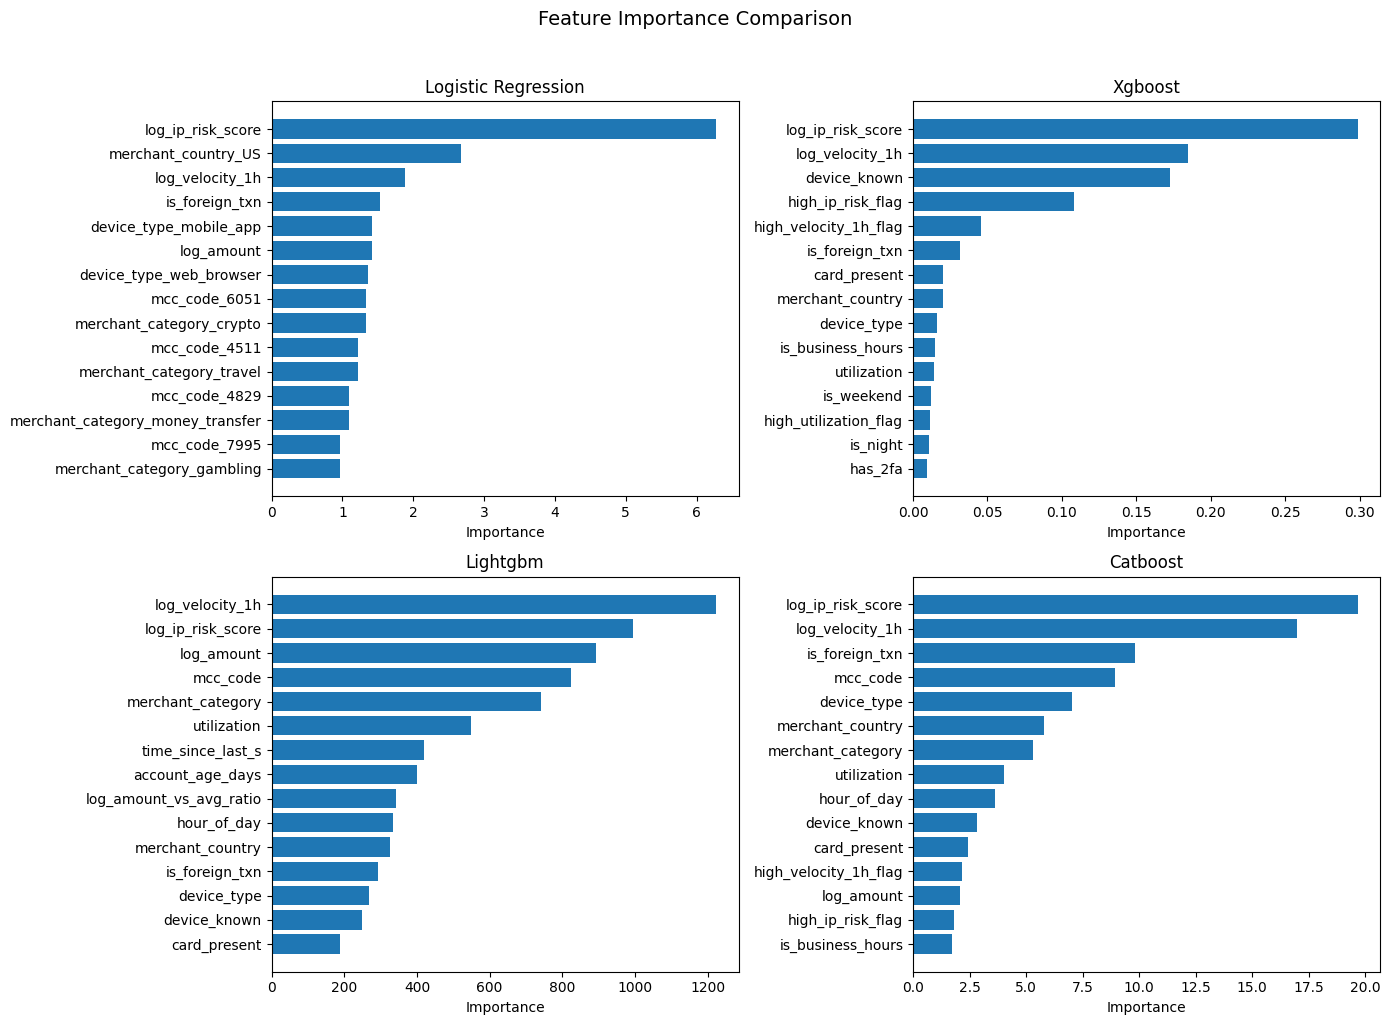

In [40]:
def plot_all_feature_importance(model_results, top_n=15, ncols=2):
    feature_models = [
        r for r in model_results
        if r.get("feature_importance_df") is not None and not r["feature_importance_df"].empty
    ]

    if not feature_models:
        print("Không có model nào có feature importance để vẽ.")
        return

    n_models = len(feature_models)
    nrows = ceil(n_models / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, result in zip(axes, feature_models):
        plot_df = (
            result["feature_importance_df"]
            .head(top_n)
            .sort_values("importance", ascending=True)
        )

        ax.barh(plot_df["feature"], plot_df["importance"])
        ax.set_title(result["display_name"])
        ax.set_xlabel("Importance")

    for ax in axes[len(feature_models):]:
        ax.axis("off")

    fig.suptitle("Feature Importance Comparison", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_all_feature_importance(model_results, top_n=15, ncols=2)

### Feature importance comparison

The feature importance plots show strong consistency across the boosting models.

Several variables appear repeatedly among the most important signals:

- `log_ip_risk_score`
- `log_velocity_1h`
- `log_amount`
- `mcc_code`
- `merchant_category`
- `merchant_country`
- `is_foreign_txn`
- `device_known`
- `utilization`
- `time_since_last_s`
- `hour_of_day`

This is encouraging because these features align well with fraud intuition. The models are relying on signals related to:

- behavioral intensity,
- device and location risk,
- unusual transaction amount,
- merchant context,
- and short-term temporal activity.

There are also subtle differences between the boosting models:

- **LightGBM** places more visible emphasis on continuous behavioral and temporal variables such as `log_amount`, `time_since_last_s`, and `account_age_days`. This may help explain its better precision and stronger PR-AUC.
- **XGBoost** relies more strongly on sharper high-risk indicators such as `device_known`, `high_ip_risk_flag`, and `high_velocity_1h_flag`, which may contribute to its slightly higher recall.
- **CatBoost** appears to use a balanced mix of continuous and categorical context signals, which is consistent with its stable but non-dominant performance profile.

By contrast, **Logistic Regression** seems to depend heavily on a smaller set of strong linear signals, especially `log_ip_risk_score`, `merchant_country_US`, and `log_velocity_1h`. This helps explain why it reacts strongly, but lacks the same ranking precision as the boosting models.

## 7. Select the Best Baseline Model

In [21]:
best_row = leaderboard.iloc[0]
best_model_name = best_row["model_name"]

best_result = next(r for r in model_results if r["model_name"] == best_model_name)

print("Best model selected:", best_result["display_name"])
print("Dataset branch     :", best_result["dataset"])
print("Use SMOTE          :", best_result["use_smote"])

pd.DataFrame(
    [
        {
            "accuracy": best_result["accuracy"],
            "precision": best_result["precision"],
            "recall": best_result["recall"],
            "f1_score": best_result["f1_score"],
            "roc_auc": best_result["roc_auc"],
            "pr_auc": best_result["pr_auc"],
        }
    ]
)

Best model selected: Lightgbm
Dataset branch     : tree
Use SMOTE          : True


,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,0.992478,0.801108,0.752492,0.776039,0.994015,0.852391


### Final comparison and decision

Taken together, the metrics, confusion matrices, PR curves, and feature importance plots all support the same conclusion.

- **Logistic Regression** is useful as a recall-heavy baseline, but not the most practical production candidate.
- **XGBoost** is the strongest choice if the main objective is to push recall slightly higher within the boosting family.
- **CatBoost** is a strong and stable alternative, but it does not lead on the main decision criteria.
- **LightGBM** offers the best overall balance between fraud capture, false positive control, and ranking quality.

Therefore, **LightGBM is the best baseline model in this notebook**. Its advantage is not based on one metric alone, but on the fact that it combines:

- the best **PR-AUC**,
- the highest **precision**,
- competitive **recall**,
- the cleanest **confusion profile**,
- and feature importance patterns that are highly plausible for fraud detection.

This makes LightGBM the most suitable model to move forward into threshold tuning and production deployment.

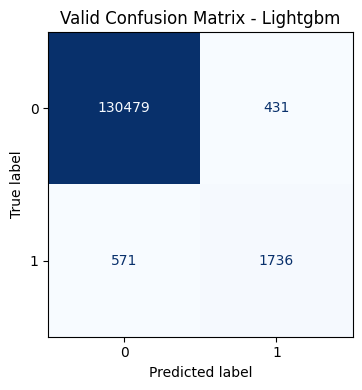

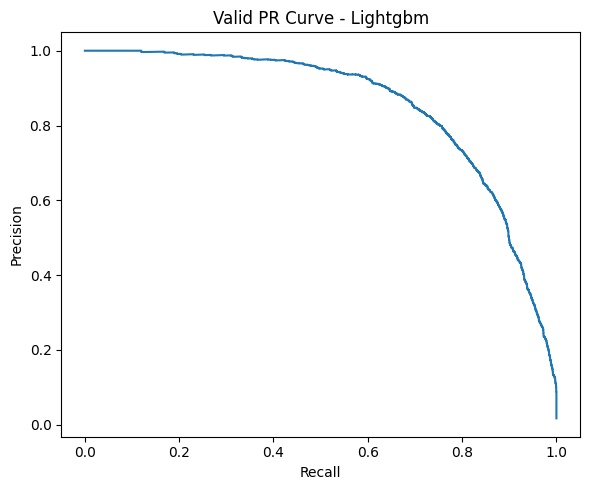

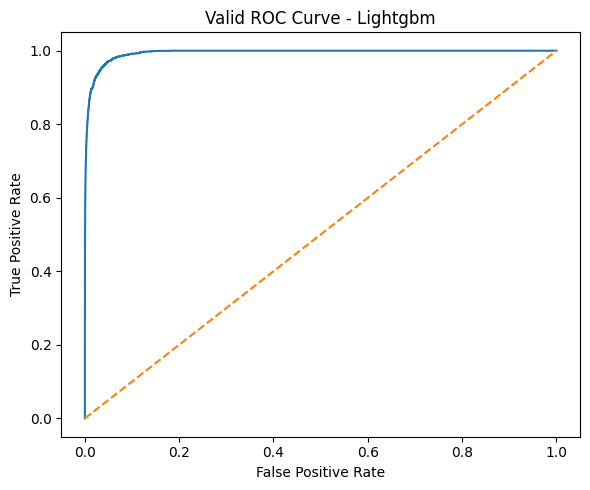

In [41]:
plot_confusion_matrix(
    y_true=best_result["y_valid_true"],
    y_pred=best_result["y_valid_pred"],
    title=f"Valid Confusion Matrix - {best_result['display_name']}",
)

plot_pr_curve(
    y_true=best_result["y_valid_true"],
    y_score=best_result["y_valid_score"],
    title=f"Valid PR Curve - {best_result['display_name']}",
)

plot_roc_curve(
    y_true=best_result["y_valid_true"],
    y_score=best_result["y_valid_score"],
    title=f"Valid ROC Curve - {best_result['display_name']}",
)

,feature,importance
0,log_velocity_1h,1224
1,log_ip_risk_score,994
2,log_amount,892
3,mcc_code,823
4,merchant_category,741
5,utilization,548
6,time_since_last_s,419
7,account_age_days,401
8,log_amount_vs_avg_ratio,343
9,hour_of_day,333


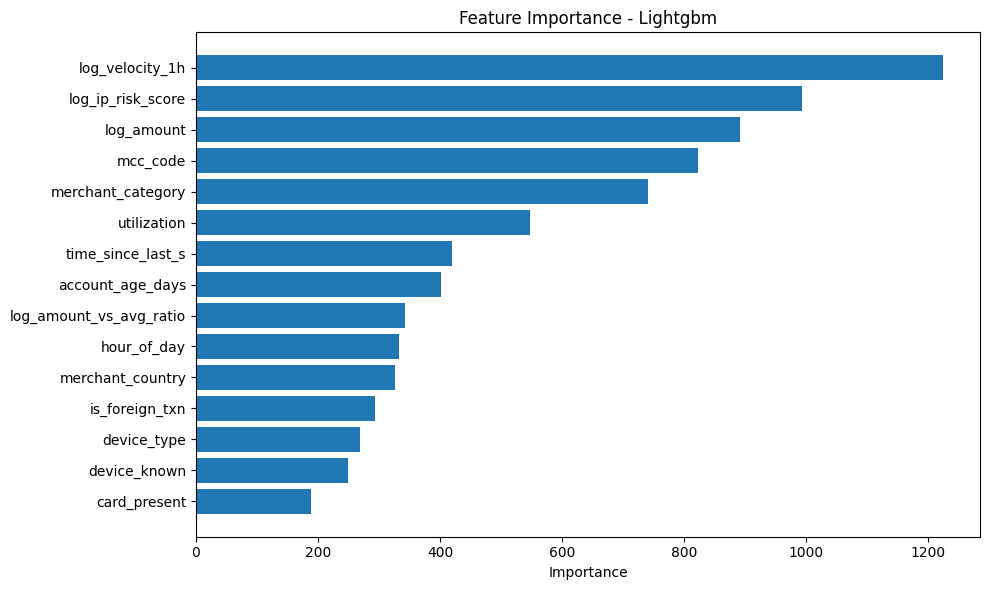

In [42]:
if best_result["feature_importance_df"] is not None:
    display(best_result["feature_importance_df"].head(20))
    plot_feature_importance(
        best_result["feature_importance_df"],
        title=f"Feature Importance - {best_result['display_name']}",
        top_n=15,
    )
else:
    print("This model does not expose feature importance.")
    